# Задача 1

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('hospital_data.csv')
df.head()

,BED,MCDAYS,TDAYS,PCREV,NSAL,FEXP,RURAL
0,244,128,385,23521,5230,5334,0
1,59,155,203,9160,2459,493,1
2,120,281,392,21900,6304,6115,0
3,120,291,419,22354,6590,6346,0
4,120,238,363,17421,5362,6225,0


In [17]:
# Разделяем данные на две независимые выборки
rural = df[df['RURAL'] == 1]['NSAL']   # загородные больницы
urban = df[df['RURAL'] == 0]['NSAL']   # городские больницы

alpha = 0.05 

Нулевая гипотеза H0: Средний годовой оклад медсестры одинаков в городских и загородных больницах.

Альтернативная гипотеза H1: Средний годовой оклад различается.

Уровень значимости: 0.05

### Проверка нормальности

In [25]:
print("Проверка нормальности (критерий Шапиро-Уилка)")

shapiro_rural = stats.shapiro(rural)
shapiro_urban = stats.shapiro(urban)

print("Загородные: p-value =", shapiro_rural.pvalue)
if shapiro_rural.pvalue > alpha:
    print("Нет оснований отвергнуть нормальность распределения.")
else:
    print("Распределение отличается от нормального.")

print()

print("Городские: p-value =", shapiro_urban.pvalue)
if shapiro_urban.pvalue > alpha:
    print("Нет оснований отвергнуть нормальность распределения.")
else:
    print("Распределение отличается от нормального.")

Проверка нормальности (критерий Шапиро-Уилка)
Загородные: p-value = 0.07178183686209806
Нет оснований отвергнуть нормальность распределения.

Городские: p-value = 0.26658938677091204
Нет оснований отвергнуть нормальность распределения.


т.к. обе выборки не противоречат нормальности, можно применять параметрический t-критерий

### Проверка равенства дисперсий

In [15]:
print("Проверка равенства дисперсий (критерий Левена)")

levene_test = stats.levene(rural, urban)
print("p-value =", levene_test.pvalue)

Проверка равенства дисперсий (критерий Левена)
p-value = 0.048949636544390614


т.к. p-value < alpha, дисперсии статистически различаются. Используем t-критерий Уэлча

### Проверка основной гипотезы

In [ ]:
print("t-критерий для независимых выборок")

ttest = stats.ttest_ind(rural, urban, equal_var=equal_var)

print("t-статистика =", ttest.statistic)
print("p-value =", ttest.pvalue)

Так как p-value < alpha, отвергаем нулевую гипотезу

### Вывод: средние оклады статистически различаются

### Визуализация данных

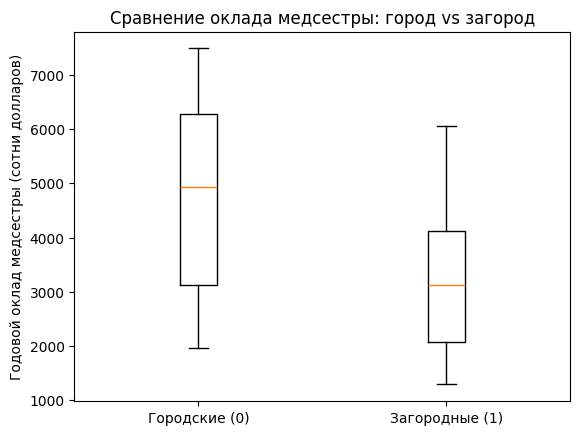

In [18]:
plt.figure()
plt.boxplot([urban, rural])
plt.xticks([1, 2], ['Городские (0)', 'Загородные (1)'])
plt.ylabel('Годовой оклад медсестры (сотни долларов)')
plt.title('Сравнение оклада медсестры: город vs загород')
plt.show()

# Задача 2

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('Unions and State Labor Law_data.csv')
df.head()

,STATE,DENS,COMP,RTW,PVT
0,NY,56.9,1,0,31.2
1,MI,49.6,1,0,30.2
2,WA,32.4,1,0,33.1
3,HI,54.6,1,0,24.7
4,AK,30.7,1,0,30.1


In [26]:
law_yes = df[df['COMP'] == 1]['PVT']   # закон действует
law_no = df[df['COMP'] == 0]['PVT']    # закон не действует

alpha = 0.05

Нулевая гипотеза H0: Средний процент муниципальных служащих в профсоюзах одинаков в штатах с законом и без закона

Альтернативная гипотеза H1: Средние значения различаются

Уровень значимости: 0.05

### Проверка нормальности

In [27]:
print("=== Проверка нормальности (Shapiro-Wilk) ===")

shapiro_yes = stats.shapiro(law_yes)
shapiro_no = stats.shapiro(law_no)

print("Закон действует: p-value =", shapiro_yes.pvalue)
if shapiro_yes.pvalue > alpha:
    print("Нет оснований отвергнуть нормальность.")
else:
    print("Распределение отличается от нормального.")

print()

print("Закон не действует: p-value =", shapiro_no.pvalue)
if shapiro_no.pvalue > alpha:
    print("Нет оснований отвергнуть нормальность.")
else:
    print("Распределение отличается от нормального.")

=== Проверка нормальности (Shapiro-Wilk) ===
Закон действует: p-value = 0.23723558460865807
Нет оснований отвергнуть нормальность.

Закон не действует: p-value = 0.0074858549423073364
Распределение отличается от нормального.


т.к. в штатах, где нет закона, распределение данных отличается от нормального, используем непараметрический критерий Манна–Уитни.

### Проверка основной гипотезы

In [31]:
print("\n=== Критерий Манна–Уитни ===")
mannwhitney = stats.mannwhitneyu(law_yes, law_no, alternative='two-sided')
print("U-статистика =", mannwhitney.statistic)
print("p-value =", mannwhitney.pvalue)
    
p_value = mannwhitney.pvalue


=== Критерий Манна–Уитни ===
U-статистика = 370.0
p-value = 0.25069218787759673


Так как p-value > alpha, нет оснований отвергать H0

### Вывод: статистически значимых различий не обнаружено

### Визуализация данных

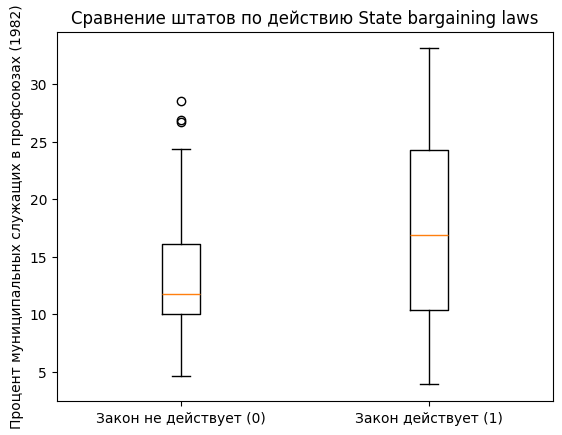

In [33]:
plt.figure()
plt.boxplot([law_no, law_yes])
plt.xticks([1, 2], ['Закон не действует (0)', 'Закон действует (1)'])
plt.ylabel('Процент муниципальных служащих в профсоюзах (1982)')
plt.title('Сравнение штатов по действию State bargaining laws')
plt.show()